In [23]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import joblib

In [2]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [3]:
df = pd.read_csv("diabetes.csv")

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [5]:
df.shape

(768, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [13]:
#Check Target Class Distribution
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


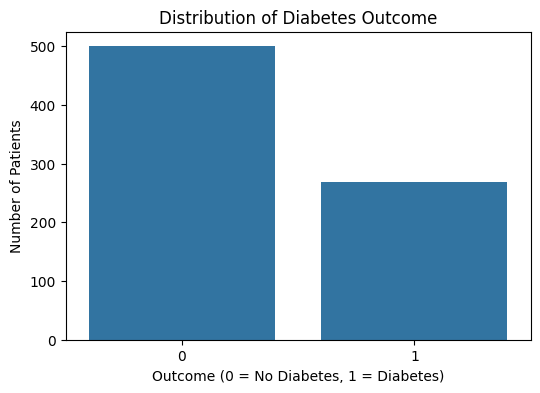

In [14]:
#Visualization
plt.figure(figsize=(6, 4))

sns.countplot(x="Outcome", data=df)

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

In [9]:
columns_to_check = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print((df[columns_to_check] == 0).sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


# Data Preprocessing

In [15]:
# Separate input features and target variable
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target (y):
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [19]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (768, 8)
Shape of y: (768,)


In [18]:
#Perform Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
#Check the Training and Testing Data Shapes
print("Training Feature Set Shape:", X_train.shape)
print("Testing Feature Set Shape:", X_test.shape)

print("Training Target Set Shape:", y_train.shape)
print("Testing Target Set Shape:", y_test.shape)

Training Feature Set Shape: (614, 8)
Testing Feature Set Shape: (154, 8)
Training Target Set Shape: (614,)
Testing Target Set Shape: (154,)


In [24]:
#Train Logistic Regression
#Fit the scaler on the training data
X_train_scaled = scaler.fit_transform(X_train)
#Transform the testing data
X_test_scaled = scaler.transform(X_test)
#Create the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
#Train the model
lr_model.fit(X_train_scaled, y_train)
#Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

#Check some predictions:

print("First 10 Predictions:")
print(y_pred_lr[:10])

print("\nActual Values:")
print(y_test.values[:10])

First 10 Predictions:
[0 0 0 0 0 0 1 1 0 1]

Actual Values:
[0 0 0 1 0 0 1 1 0 0]


In [21]:
#Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
#Train the model
rf_model.fit(X_train, y_train)
#Make predictions
y_pred_rf = rf_model.predict(X_test)

#Check some predictions:

print("First 10 Predictions:")
print(y_pred_rf[:10])

print("\nActual Values:")
print(y_test.values[:10])

First 10 Predictions:
[0 0 0 1 0 0 1 1 0 1]

Actual Values:
[0 0 0 1 0 0 1 1 0 0]


In [22]:
#Train Support Vector Machine (SVM)
#Create the SVM model
svm_model = SVC(
    probability=True,
    random_state=42
)
#Train the model
svm_model.fit(X_train_scaled, y_train)
#Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

#Check some predictions:

print("First 10 Predictions:")
print(y_pred_svm[:10])

print("\nActual Values:")
print(y_test.values[:10])

First 10 Predictions:
[0 0 0 1 0 0 1 1 0 1]

Actual Values:
[0 0 0 1 0 0 1 1 0 0]


# Model Evaluation

In [25]:
#Get Prediction Probabilities

# Logistic Regression probabilities
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Random Forest probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# SVM probabilities
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

In [26]:
#Evaluate Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1 Score:  {f1_lr:.4f}")
print(f"ROC-AUC:   {roc_auc_lr:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy:  0.7078
Precision: 0.5882
Recall:    0.5556
F1 Score:  0.5714
ROC-AUC:   0.8263


In [27]:
#Evaluate Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")

Random Forest Results
-----------------------------------
Accuracy:  0.8636
Precision: 0.8113
Recall:    0.7963
F1 Score:  0.8037
ROC-AUC:   0.9436


In [28]:
#Evaluate SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

print("SVM Results")
print("-" * 35)
print(f"Accuracy:  {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1 Score:  {f1_svm:.4f}")
print(f"ROC-AUC:   {roc_auc_svm:.4f}")

SVM Results
-----------------------------------
Accuracy:  0.8377
Precision: 0.7636
Recall:    0.7778
F1 Score:  0.7706
ROC-AUC:   0.8974


In [29]:
#Create a Model Performance Comparison Table

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_rf,
        accuracy_svm
    ],

    "Precision": [
        precision_lr,
        precision_rf,
        precision_svm
    ],

    "Recall": [
        recall_lr,
        recall_rf,
        recall_svm
    ],

    "F1 Score": [
        f1_lr,
        f1_rf,
        f1_svm
    ],

    "ROC-AUC Score": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_svm
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC Score
0,Logistic Regression,0.7078,0.5882,0.5556,0.5714,0.8263
1,Random Forest,0.8636,0.8113,0.7963,0.8037,0.9436
2,SVM,0.8377,0.7636,0.7778,0.7706,0.8974


In [30]:
#Plot the ROC Curves

# Logistic Regression ROC values
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

# Random Forest ROC values
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# SVM ROC values
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

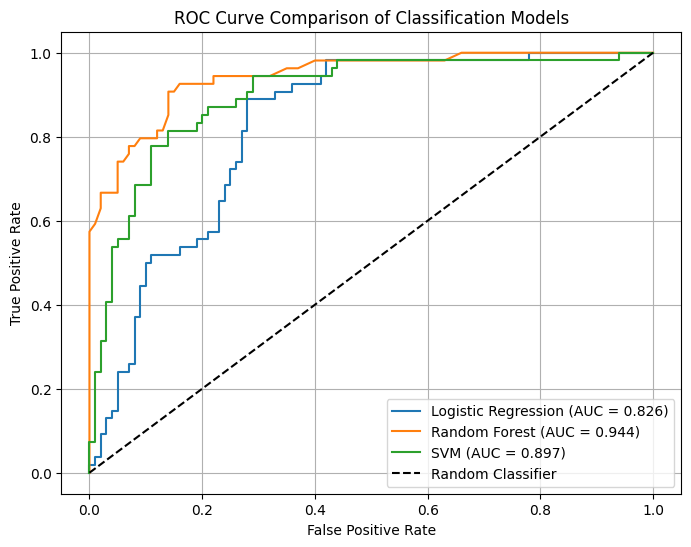

In [31]:
plt.figure(figsize=(8, 6))

# Logistic Regression
plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})"
)

# Random Forest
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

# SVM
plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {roc_auc_svm:.3f})"
)

# Random classifier line
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Classification Models")

plt.legend()
plt.grid(True)

plt.show()

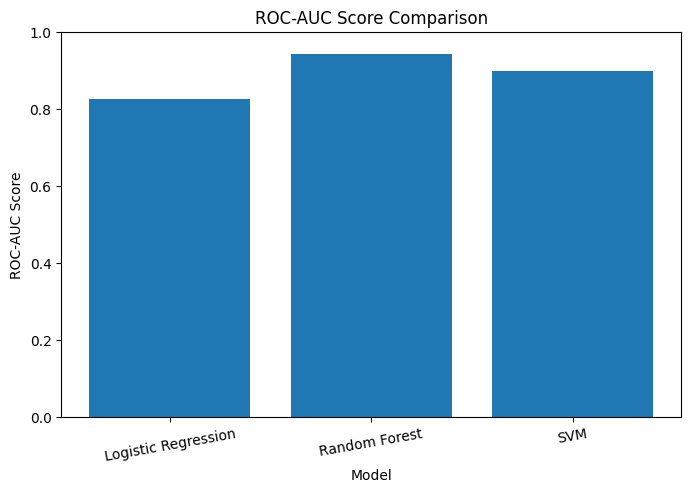

In [32]:
#Compare ROC-AUC Scores Visually
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["ROC-AUC Score"]
)

plt.title("ROC-AUC Score Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC Score")

plt.ylim(0, 1)

plt.xticks(rotation=10)

plt.show()

In [33]:
#Select the Best Model

best_model_index = results["ROC-AUC Score"].idxmax()

best_model_name = results.loc[
    best_model_index,
    "Model"
]

best_roc_auc = results.loc[
    best_model_index,
    "ROC-AUC Score"
]

print("Best Model:", best_model_name)
print("Best ROC-AUC Score:", round(best_roc_auc, 4))

Best Model: Random Forest
Best ROC-AUC Score: 0.9436


In [34]:
results.sort_values(
    by="ROC-AUC Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC Score
1,Random Forest,0.863636,0.811321,0.796296,0.803738,0.943611
2,SVM,0.837662,0.763636,0.777778,0.770642,0.897407
0,Logistic Regression,0.707792,0.588235,0.555556,0.571429,0.826296


# Save the Best Model Using Joblib

In [36]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "SVM": svm_model
}
best_model = models[best_model_name]
joblib.dump(best_model, "best_diabetes_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!
